<a href="https://colab.research.google.com/github/blackArcher33/drug_efectiveness_project/blob/main/Drug_efectiveness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [536]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [387]:
df =pd.read_csv("healthcare_drug.csv")

In [388]:
df

,Age,Gender,Treatment,BP_Before,BP_After,RecoveryDays,PainScore,Recovered,BP_Reduction
0,63,M,B,148,116,4,3,No,32
1,76,M,C,145,124,6,5,Yes,21
2,53,F,B,148,120,5,1,Yes,28
3,39,M,A,178,158,5,3,Yes,20
4,67,M,A,170,148,6,4,No,22
...,...,...,...,...,...,...,...,...,...
495,29,F,A,174,162,11,5,Yes,12
496,63,M,C,141,111,3,3,Yes,30
497,28,F,C,166,139,6,3,Yes,27
498,30,F,A,141,125,6,3,Yes,16


In [389]:
df.describe()

,Age,BP_Before,BP_After,RecoveryDays,PainScore,BP_Reduction
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,52.834000,159.352000,134.248000,5.662000,3.06600,25.104000
std,15.992184,11.956002,15.506237,2.229281,1.52522,9.433513
min,25.000000,140.000000,98.000000,3.000000,1.00000,8.000000
25%,40.000000,149.000000,122.000000,4.000000,2.00000,18.000000
50%,53.000000,159.000000,134.000000,5.000000,3.00000,24.000000
75%,66.000000,170.000000,146.000000,7.000000,4.00000,32.000000
max,80.000000,180.000000,172.000000,13.000000,7.00000,45.000000


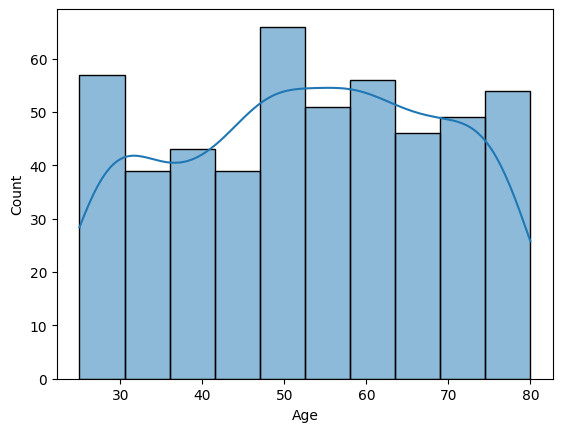

In [390]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Age"],bins=10,kde=True)
plt.show()

In [291]:
df["Gender"].value_counts()


,count
Gender,
F,252
M,248


In [292]:
df["Gender"].value_counts(normalize=True)*100

,proportion
Gender,
F,50.4
M,49.6


In [293]:
df["Treatment"].value_counts()

,count
Treatment,
C,178
B,165
A,157


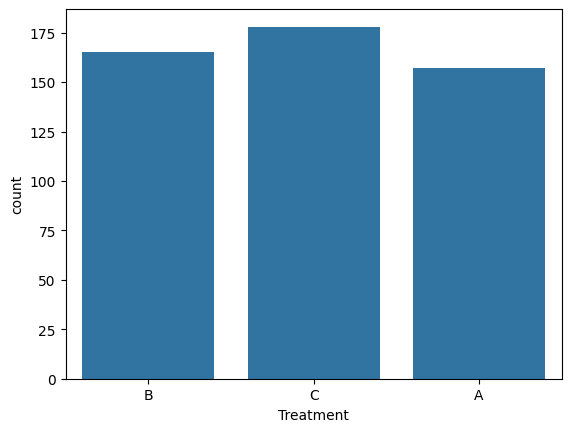

In [294]:
sns.countplot(
    x="Treatment",
    data=df
)
plt.show()

In [295]:
df["Recovered"].value_counts()

,count
Recovered,
Yes,336
No,164


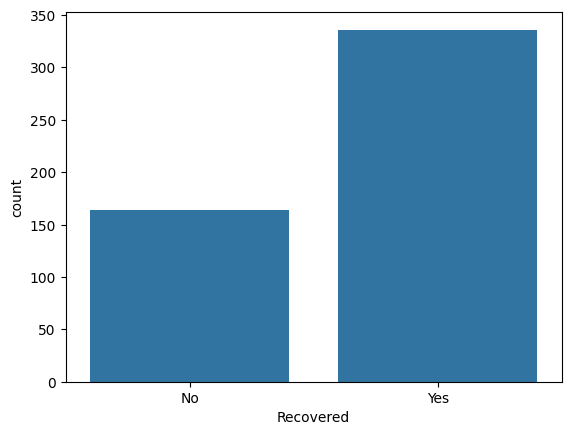

In [296]:
sns.countplot(
    x="Recovered",
    data=df
)
plt.show()

In [297]:
pd.crosstab(
    df["Treatment"],
    df["Recovered"]
)

Recovered,No,Yes
Treatment,,
A,91,66
B,54,111
C,19,159


In [298]:
df.isnull().sum()

,0
Age,0
Gender,0
Treatment,0
BP_Before,0
BP_After,0
RecoveryDays,0
PainScore,0
Recovered,0
BP_Reduction,0


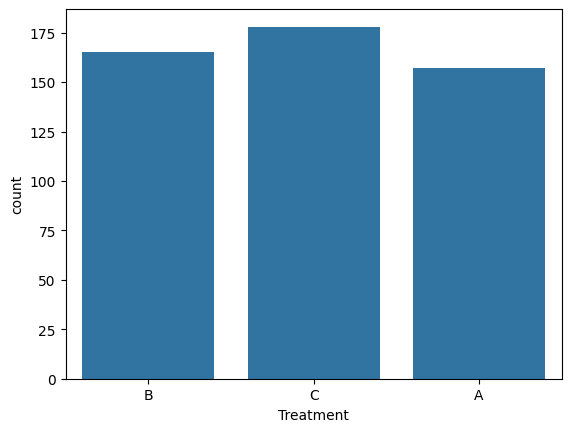

In [299]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Treatment',
    data=df
)

plt.show()

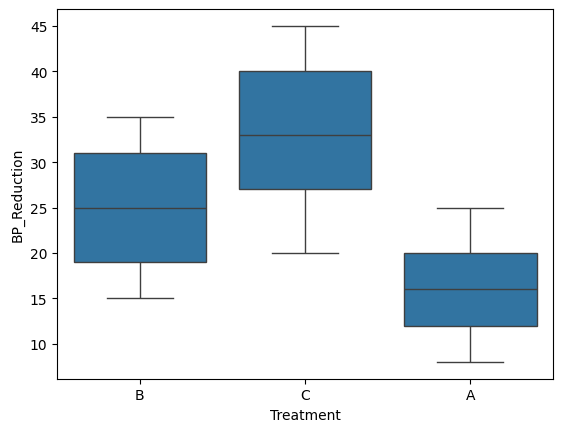

In [302]:
sns.boxplot(
    x='Treatment',
    y='BP_Reduction',
    data=df
)

plt.show()

Statistical Tests

# ANOVA Test

In [397]:
# ANOVA Test
# Do all drugs reduce BP equally?

from scipy.stats import f_oneway

In [398]:
# H0:All drugs have same mean BP reduction.
# H1: At least one drug differs.
A=df[df["Treatment"]=="A"]["BP_Reduction"]
B=df[df["Treatment"]=="B"]["BP_Reduction"]
C=df[df["Treatment"]=="C"]["BP_Reduction"]

In [399]:
f,p_anova=f_oneway(A,B,C)
print(f,p_anova)

307.9727847057301 9.903581061840873e-88


In [400]:
if p_anova<0.05:
    print("Drug effectiveness differs")
else:
    print("No significant difference")

Drug effectiveness differs


# t -Test

In [404]:
# Male vs Female BP Reduction?
# H0: Same mean reduction.

from scipy.stats import ttest_ind

In [407]:
male=df[df["Gender"]=="M"]["BP_Reduction"]
female=df[df["Gender"]=="F"]["BP_Reduction"]

In [410]:
t,p_ttest=ttest_ind(
    male,
    female
)

In [411]:
print(t,p_ttest)

0.030386774487608497 0.975770766219694


# Z TEST

In [412]:
# Large sample comparison.

from statsmodels.stats.weightstats import ztest


In [413]:
B=df[df["Treatment"]=="B"]["BP_Reduction"]
C=df[df["Treatment"]=="C"]["BP_Reduction"]


In [416]:
z,p_ztest=ztest(B,C)

print(z,p_ztest)

-11.181763075921582 5.008494787640133e-29


# U Test

In [417]:
# Non-parametric version of t-test.

from scipy.stats import mannwhitneyu


In [418]:
# Compare recovery days.
male=df[df["Gender"]=="M"]["RecoveryDays"]
female=df[df["Gender"]=="F"]["RecoveryDays"]

In [420]:
u,p_utest=mannwhitneyu(
    male,
    female
)
print(u,p_utest)

31038.0 0.8954582329665143


# Chi-Square Test

In [317]:
# Does drug affect recovery?
# H0: Drug and Recovery independent.
# H1: Drug affects recovery.

In [421]:
from scipy.stats import chi2_contingency

In [422]:
table=pd.crosstab(
    df["Treatment"],
    df["Recovered"]
)

In [320]:
table

Recovered,No,Yes
Treatment,,
A,91,66
B,54,111
C,19,159


In [423]:
chi,p_chi,dof,expected=chi2_contingency(table)

In [425]:
print(chi,p_chi)

84.63106167566794 4.1937106096124455e-19


In [426]:
if p_chi<0.05:
    print("Treatment affects recovery")
else:
    print("No significant affect")

Treatment affects recovery


In [519]:
corr_df = df.copy()

In [520]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

corr_df["Gender"] = le.fit_transform(corr_df["Gender"])

corr_df["Treatment"] = le.fit_transform(corr_df["Treatment"])

corr_df["Recovered"] = le.fit_transform(corr_df["Recovered"])

In [521]:
corr = corr_df.corr()

corr

,Age,Gender,Treatment,BP_Before,BP_After,RecoveryDays,PainScore,Recovered,BP_Reduction
Age,1.000000,0.143761,0.028559,-0.004180,-0.013524,-0.045816,-0.057719,-0.039523,0.016932
Gender,0.143761,1.000000,0.056685,-0.029906,-0.023887,-0.003908,0.025287,-0.039670,0.001362
Treatment,0.028559,0.056685,1.000000,-0.054977,-0.494860,-0.508539,-0.353876,0.411107,0.743743
BP_Before,-0.004180,-0.029906,-0.054977,1.000000,0.793986,0.037255,0.004108,-0.005447,-0.037709
BP_After,-0.013524,-0.023887,-0.494860,0.793986,1.000000,0.430041,0.272575,-0.217617,-0.637444
RecoveryDays,-0.045816,-0.003908,-0.508539,0.037255,0.430041,1.000000,0.314824,-0.236105,-0.659659
PainScore,-0.057719,0.025287,-0.353876,0.004108,0.272575,0.314824,1.000000,-0.154263,-0.442836
Recovered,-0.039523,-0.039670,0.411107,-0.005447,-0.217617,-0.236105,-0.154263,1.000000,0.350803
BP_Reduction,0.016932,0.001362,0.743743,-0.037709,-0.637444,-0.659659,-0.442836,0.350803,1.000000


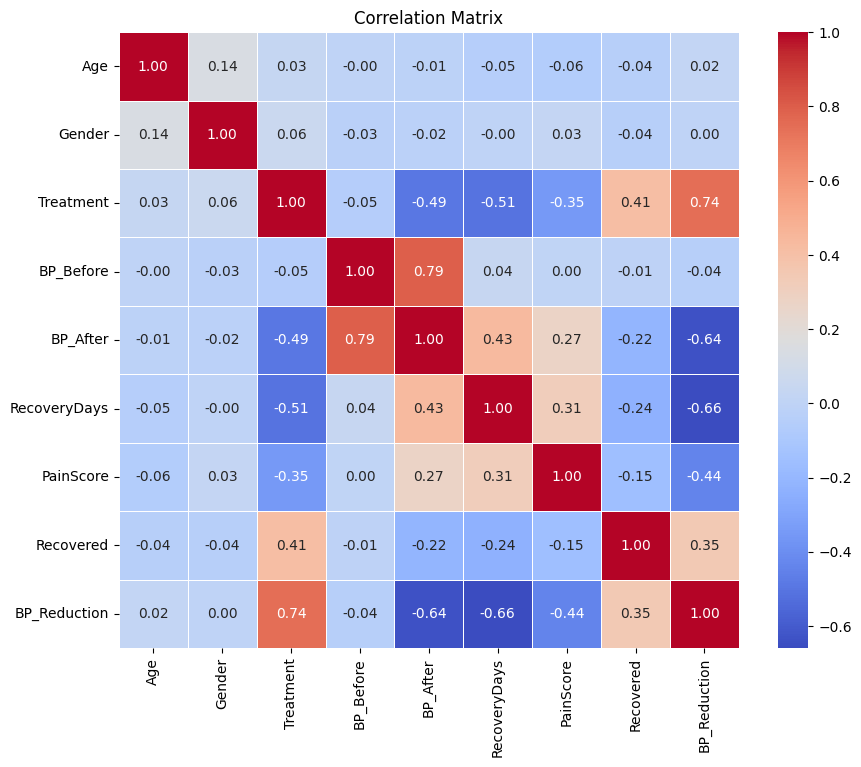

In [522]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.savefig(
    "Project_Output/Plots/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [523]:
target_corr = corr["Recovered"].sort_values(ascending=False)

print(target_corr)

Recovered       1.000000
Treatment       0.411107
BP_Reduction    0.350803
BP_Before      -0.005447
Age            -0.039523
Gender         -0.039670
PainScore      -0.154263
BP_After       -0.217617
RecoveryDays   -0.236105
Name: Recovered, dtype: float64


In [526]:
target_corr.to_csv(
    "Project_Output/EDA/target_correlation.csv"
)

Logistic Regression

In [524]:
# first use lable encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Treatment"] = le.fit_transform(df["Treatment"])
df["Recovered"] = le.fit_transform(df["Recovered"])

In [525]:
df.head()

,Age,Gender,Treatment,BP_Before,BP_After,RecoveryDays,PainScore,Recovered,BP_Reduction
0,63,1,1,148,116,4,3,0,32
1,76,1,2,145,124,6,5,1,21
2,53,0,1,148,120,5,1,1,28
3,39,1,0,178,158,5,3,1,20
4,67,1,0,170,148,6,4,0,22


In [452]:
X = df.drop("Recovered",axis=1)

y = df["Recovered"]

In [453]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [454]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [432]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [433]:
y_pred = lr.predict(X_test)

In [434]:
y_pred

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0])

In [438]:
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test,y_pred)
print("Accuracy =",lr_accuracy)

Accuracy = 0.71


In [440]:
from sklearn.metrics import confusion_matrix
lr_cm = confusion_matrix(
    y_test,
    y_pred
)
print(lr_cm)

[[21 17]
 [12 50]]


In [441]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.64      0.55      0.59        38
           1       0.75      0.81      0.78        62

    accuracy                           0.71       100
   macro avg       0.69      0.68      0.68       100
weighted avg       0.70      0.71      0.71       100



In [442]:
df

,Age,Gender,Treatment,BP_Before,BP_After,RecoveryDays,PainScore,Recovered,BP_Reduction
0,63,1,1,148,116,4,3,0,32
1,76,1,2,145,124,6,5,1,21
2,53,0,1,148,120,5,1,1,28
3,39,1,0,178,158,5,3,1,20
4,67,1,0,170,148,6,4,0,22
...,...,...,...,...,...,...,...,...,...
495,29,0,0,174,162,11,5,1,12
496,63,1,2,141,111,3,3,1,30
497,28,0,2,166,139,6,3,1,27
498,30,0,0,141,125,6,3,1,16


In [443]:
X = df[
[
'Age',
'Gender',
'Treatment',
'BP_Before',
'BP_After',
'PainScore',
'BP_Reduction'
]
]

In [444]:
y = df["Recovered"]

In [445]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [455]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [447]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [448]:
y_pred = lr.predict(X_test)

In [449]:
y_pred

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0])

In [527]:
lr_accuracy = accuracy_score(y_test,y_pred)
print("Accuracy =",lr_accuracy)

Accuracy = 0.69


In [354]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    y_pred
)
print(cm)

[[21 17]
 [13 49]]


In [456]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.62      0.55      0.58        38
           1       0.74      0.79      0.77        62

    accuracy                           0.70       100
   macro avg       0.68      0.67      0.67       100
weighted avg       0.70      0.70      0.70       100



Decision Tree

In [457]:
from sklearn.tree import DecisionTreeClassifier

In [458]:
df.head()

,Age,Gender,Treatment,BP_Before,BP_After,RecoveryDays,PainScore,Recovered,BP_Reduction
0,63,1,1,148,116,4,3,0,32
1,76,1,2,145,124,6,5,1,21
2,53,0,1,148,120,5,1,1,28
3,39,1,0,178,158,5,3,1,20
4,67,1,0,170,148,6,4,0,22


In [459]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [460]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [461]:
y_pred = dt.predict(X_test)

In [530]:
dt_accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",dt_accuracy)

Accuracy: 0.69


In [464]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.49      0.45      0.47        38
           1       0.68      0.71      0.69        62

    accuracy                           0.61       100
   macro avg       0.58      0.58      0.58       100
weighted avg       0.60      0.61      0.61       100



In [505]:
print(confusion_matrix(y_test,y_pred))

[[14 24]
 [ 7 55]]


In [506]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':dt.feature_importances_

})

dt_importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(dt_importance)

        Feature  Importance
0           Age    0.279955
2     Treatment    0.176954
3     BP_Before    0.160241
4      BP_After    0.109127
6     PainScore    0.096849
7  BP_Reduction    0.083650
5  RecoveryDays    0.081637
1        Gender    0.011586


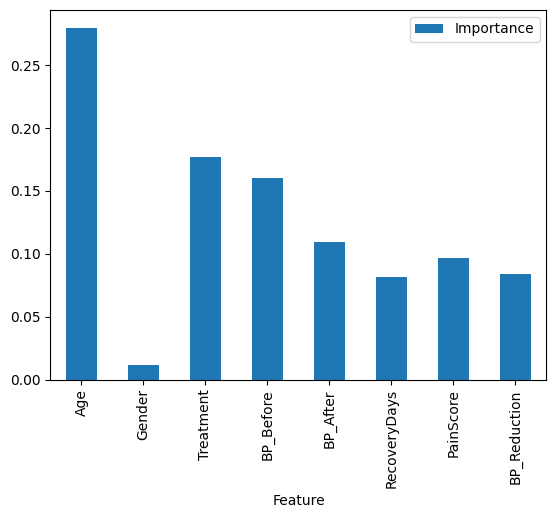

In [508]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)
plt.savefig(
    "Project_Output/Plots/dt_feature_importance.png",
    bbox_inches="tight"
)


plt.show()

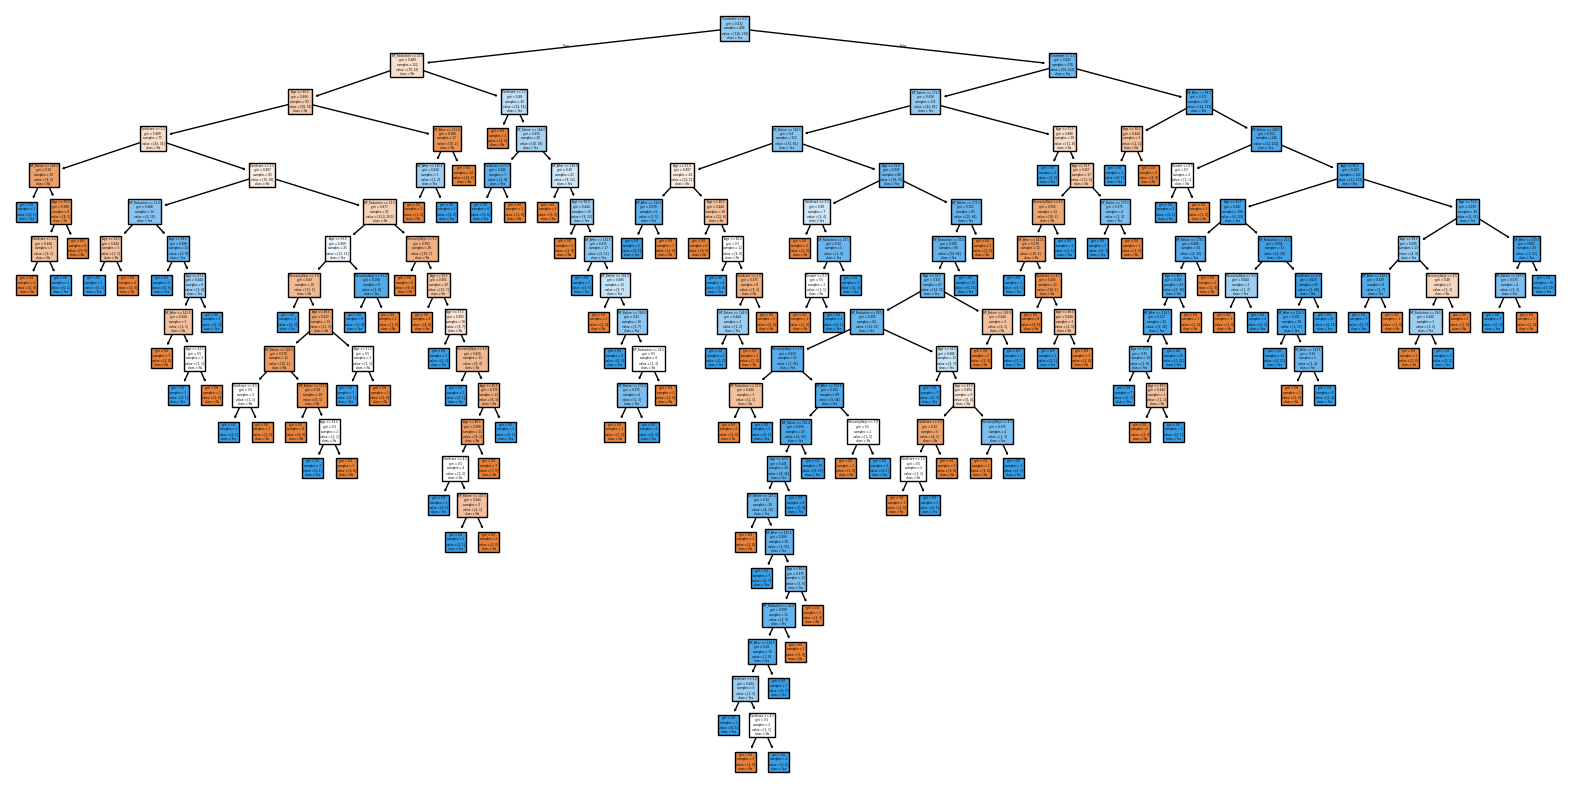

In [509]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)
plt.savefig(
    "Project_Output/Plots/decision_tree.png",
    bbox_inches="tight"
)

plt.show()

Random Forest

In [500]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

In [529]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",rf_accuracy)

Accuracy: 0.69


In [514]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.37      0.47        38
           1       0.70      0.89      0.78        62

    accuracy                           0.69       100
   macro avg       0.68      0.63      0.63       100
weighted avg       0.68      0.69      0.66       100



In [515]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

rf_importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(rf_importance)

        Feature  Importance
7  BP_Reduction    0.188452
4      BP_After    0.170185
0           Age    0.158220
3     BP_Before    0.150600
2     Treatment    0.106956
5  RecoveryDays    0.103666
6     PainScore    0.089566
1        Gender    0.032356


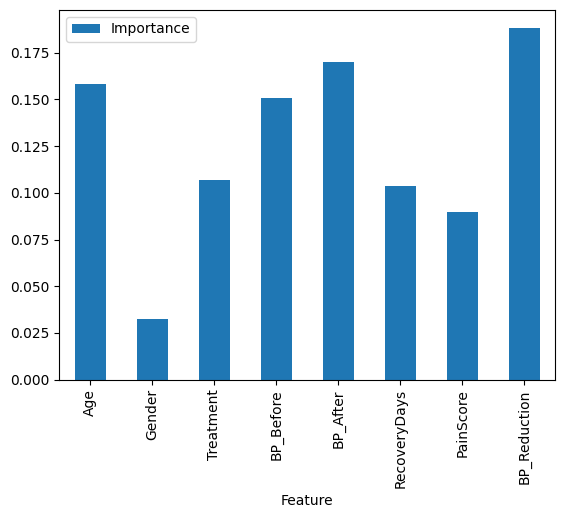

In [516]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)
plt.savefig(
    "Project_Output/Plots/rf_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

Xgboost

In [490]:
from xgboost import XGBClassifier

In [491]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [492]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [493]:
xg_accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",xg_accuracy)

Accuracy: 0.69


In [494]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.37      0.47        38
           1       0.70      0.89      0.78        62

    accuracy                           0.69       100
   macro avg       0.68      0.63      0.63       100
weighted avg       0.68      0.69      0.66       100



In [495]:
xg_cm = confusion_matrix(y_test,y_pred)
print(xg_cm)

[[14 24]
 [ 7 55]]


In [517]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xg_importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(xg_importance)

        Feature  Importance
2     Treatment    0.428511
7  BP_Reduction    0.100768
1        Gender    0.092596
6     PainScore    0.083321
3     BP_Before    0.081651
4      BP_After    0.080393
0           Age    0.079140
5  RecoveryDays    0.053618


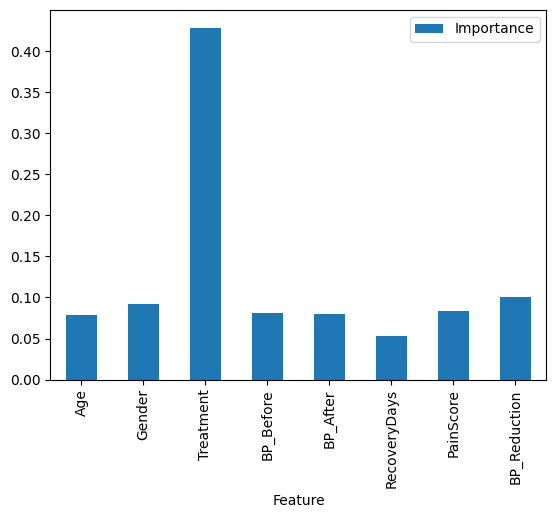

In [518]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)
plt.savefig(
    "Project_Output/Plots/xg_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [383]:
import os

folders = [
    "Project_Output",
    "Project_Output/Data",
    "Project_Output/EDA",
    "Project_Output/Statistics",
    "Project_Output/Models",
    "Project_Output/Plots",
    "Project_Output/Reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [384]:
df.to_csv(
    "Project_Output/Data/cleaned_dataset.csv",
    index=False
)

In [385]:
summary = df.describe()

summary.to_csv(
    "Project_Output/EDA/data_summary.csv"
)

In [386]:
missing = df.isnull().sum()

missing.to_csv(
    "Project_Output/EDA/missing_values.csv"
)

In [498]:
results = {
    "ANOVA_pvalue": p_anova,
    "Ttest_pvalue": p_ttest,
    "Ztest_pvalue": p_ztest,
    "Utest_pvalue": p_utest,
    "ChiSquare_pvalue": p_chi
}

import pandas as pd

stats_df = pd.DataFrame(
    results.items(),
    columns=["Test","P_Value"]
)

stats_df.to_csv(
    "Project_Output/Statistics/statistical_results.csv",
    index=False
)

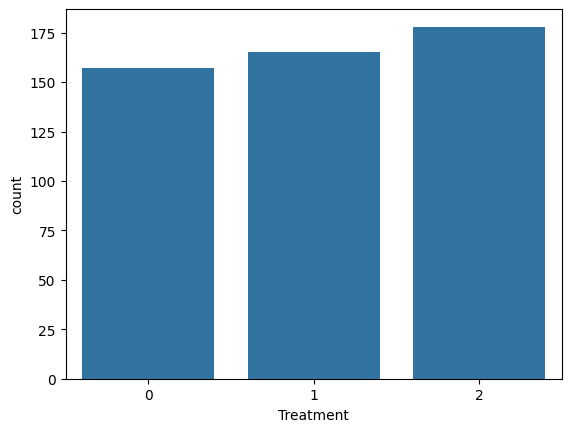

In [499]:
import matplotlib.pyplot as plt

sns.countplot(
    x="Treatment",
    data=df
)

plt.savefig(
    "Project_Output/Plots/treatment_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [528]:
model_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xg_accuracy
    ]
})

model_results.to_csv(
    "Project_Output/Models/model_comparison.csv",
    index=False
)

In [531]:
with open(
    "Project_Output/Reports/final_report.txt",
    "w"
) as f:

    f.write("""
Healthcare Drug Effectiveness Analysis

Best Model:
XG Boost

Accuracy:
69%

Most Important Features:
1. Treatment
2. BP_Reduction
3. Age

Conclusion:
Treatment and BP reduction are the major factors influencing patient recovery.
""")

In [533]:
!git clone https://github.com/blackArcher33/drug_efectiveness_project.git

Cloning into 'drug_efectiveness_project'...


In [535]:
!cp "Drug_efectiveness.ipynb" Healthcare-Drug-Analysis/

cp: cannot stat 'Drug_efectiveness.ipynb': No such file or directory
